# Dataset Statistics

For use in Figure 3.

Table of Contents:
1. Imports and load data
2. Subject statistics summary
3. Test-path statistics summary
4. Plot subject and path accuracy CDFs (Fig. 3A-B)
5. Directional path accuracy differences (Fig. 3C)
6. Effect of start vs. end node on accuracy (Fig. 3D)
7. Heatmaps and foils (Fig. 3E)
8. Miscellaneous Archives

## 1. Imports and load data

In [1]:
import matplotlib.pyplot as plt
import numpy as np  
import pandas as pd 
import plotly.graph_objs as go
import warnings

from plotly.offline import plot
from plotly.subplots import make_subplots

from scipy import stats

from flow_tree_utils import generate_trajs_from_df, load_test_df, OBJECTS

warnings.filterwarnings("ignore")
pd.options.mode.chained_assignment = None

# Lo0at data into dataframe
test_df = load_test_df()

## 2. Subject statistics summary 

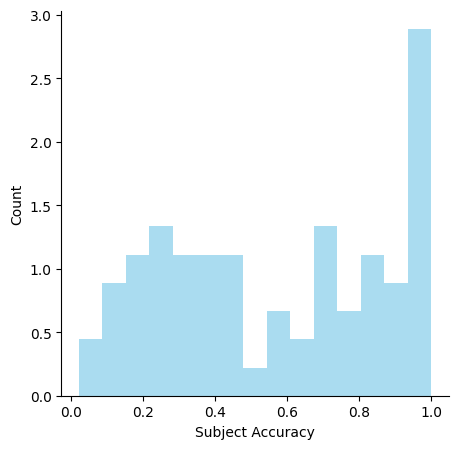


Summary Statistics of Subject Accuracies:
count    3312.000000
mean        0.569444
std         0.306964
min         0.020833
25%         0.312500
50%         0.604167
75%         0.854167
max         1.000000
Name: subj_mean_acc, dtype: float64


In [23]:
# Create a histogram to show probability distribution
plt.figure(figsize=(5,5))
plt.hist(test_df['subj_mean_acc'], bins=15, density=True, alpha=0.7, color='skyblue')

plt.grid(True, linestyle='--', alpha=0.7)
plt.xlabel('Subject Accuracy')
plt.ylabel('Count')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(False)

plt.show()

# Show summary statistics
print("\nSummary Statistics of Subject Accuracies:")
print(test_df['subj_mean_acc'].describe())

## 3. Test-path statistics summary

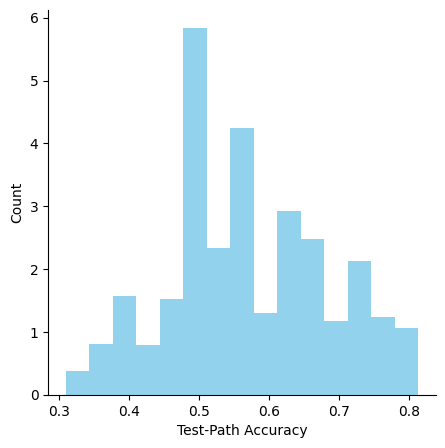


Summary Statistics of Start-End Path Accuracies:
Min: 0.30952380952380953
Max: 0.8125
Mean: 0.5694444444444459
Std: 0.11323953541441104

Summary Statistics of Start-End Path Attempt Counts:
Min: 27
Max: 70
Mean: 46.0
Std: 4.626926701842741


In [24]:
# Create a histogram to show probability distribution
plt.figure(figsize=(5,5))
plt.hist(test_df["path_mean_acc"], bins=15, density=True, alpha=0.9, color='skyblue')

plt.grid(True, linestyle='--', alpha=0.7)
plt.xlabel('Test-Path Accuracy')
plt.ylabel('Count')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(False)

plt.show()

# Show summary statistics
print("\nSummary Statistics of Start-End Path Accuracies:")
print(f"Min: {test_df['path_mean_acc'].min()}")
print(f"Max: {test_df['path_mean_acc'].max()}")
print(f"Mean: {test_df['path_mean_acc'].mean()}")
print(f"Std: {test_df['path_mean_acc'].std()}")

# Show summary statistics of counts
count_df = test_df.groupby("StartEnd").agg(
        correct_count=("accuracy", lambda x: (x == 1).sum()),
        total_count=("accuracy", "count")
    ).reset_index()

print("\nSummary Statistics of Start-End Path Attempt Counts:")
print(f"Min: {count_df['total_count'].min()}")
print(f"Max: {count_df['total_count'].max()}")
print(f"Mean: {count_df['total_count'].mean()}")
print(f"Std: {count_df['total_count'].std()}")

## 4. Plot subject and path accuracy CDFs (Fig. 3A-B)

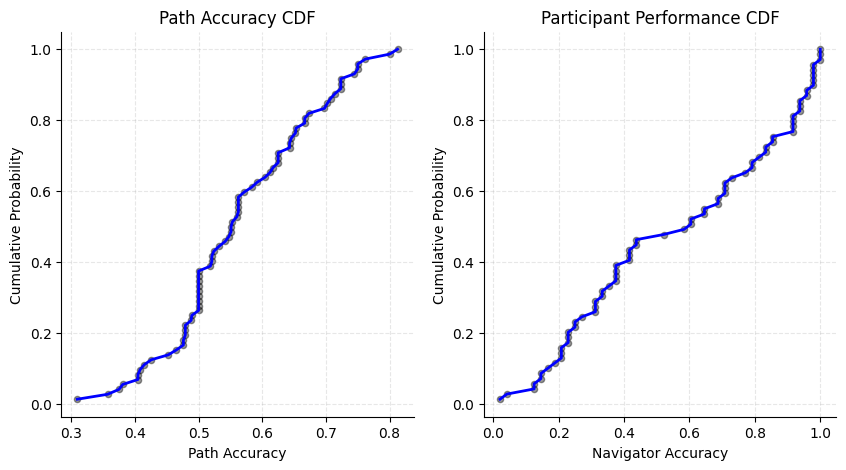

In [40]:
# Create a figure with three subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# 1. CDF of path accuracies
path_data = test_df.groupby("StartEnd")["accuracy"].apply(np.mean)
sorted_data = np.sort(path_data.values)
cumulative_prob = np.arange(1, len(sorted_data) + 1) / len(sorted_data)

ax1.plot(sorted_data, cumulative_prob, 'b-', linewidth=2)
ax1.scatter(sorted_data, cumulative_prob, alpha=0.4, color='black', s=20)
ax1.set_xlabel('Path Accuracy')
ax1.set_ylabel('Cumulative Probability')
ax1.set_title('Path Accuracy CDF')
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# 2. CDF of navigator accuracies
subject_data = test_df.groupby("Subject")["accuracy"].apply(np.mean)
sorted_data = np.sort(subject_data.values)
cumulative_prob = np.arange(1, len(sorted_data) + 1) / len(sorted_data)

ax2.plot(sorted_data, cumulative_prob, 'b-', linewidth=2)
ax2.scatter(sorted_data, cumulative_prob, alpha=0.4, color='black', s=20)
ax2.set_xlabel('Navigator Accuracy')
ax2.set_ylabel('Cumulative Probability')
ax2.set_title('Participant Performance CDF')
ax2.grid(True, linestyle='--', alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

## 5. Directional path accuracy differences (Fig. 3C)

In [55]:
# Plot accuracy differences!
acc_differences = {}
allacc1 = []
allacc2 = []
accs = {}
rev_accs = {}
p_valuesd = {}
obj_pairs = []
p_values = []
for i in range(len(OBJECTS)):
    for j in range(i+1, len(OBJECTS)):
        start_node, end_node = OBJECTS[i], OBJECTS[j]
        
        accs1 = test_df[(test_df["StartAt"]==start_node) & (test_df["EndAt"]==end_node)]["accuracy"]
        accs2 = test_df[(test_df["StartAt"]==end_node) & (test_df["EndAt"]==start_node)]["accuracy"]

        # Perform Mann-Whitney U test since we can't assume normal distribution
        statistic, p_value = stats.mannwhitneyu(accs1, accs2, alternative='two-sided')
        
        acc1 = np.mean(accs1)
        acc2 = np.mean(accs2)

        allacc1.append(acc1)
        allacc2.append(acc2)

        better_path = (start_node, end_node) if acc1 > acc2 else (end_node, start_node)
        
        accs[better_path] = max(acc1, acc2)
        rev_accs[better_path] = min(acc1, acc2)
        
        acc_differences[better_path] = np.abs(acc1 - acc2)
        p_valuesd[better_path] = p_value
        p_values.append(p_value)
        obj_pairs.append(OBJECTS[i]+OBJECTS[j])

# Apply Benjamini-Hochberg correction for false positives
# Bonferroni is another possiblity, but allegedly too stringent
bh_p_values = stats.false_discovery_control(p_values, method="bh")

print(p_values)
print(bh_p_values)
# Count how many significant differences we have after correction
print(f"Number of significant differences after Bonferroni correction (p < {.05/36:.5f}): {sum(p < .05/36 for p in p_values)}")
print(f"Number of significant differences after Benjamini-Hochberg correction: {sum(p < .05 for p in bh_p_values)}")

# Convert acc_differences dict to lists for plotting and sort by difference
sorted_items = sorted(acc_differences.items(), key=lambda x: x[1], reverse=True)
x_vals = []
y_vals = []
y1_vals = []
y2_vals = []
p_vals = []
hover_text = []
for (start, end), diff in sorted_items:
    x_vals.append(f"{start}_{end}")
    y_vals.append(diff)
    y1_vals.append(accs[(start, end)])
    y2_vals.append(rev_accs[(start, end)])
    p_vals.append(p_valuesd[(start, end)])
    hover_text.append(f"Start: {start}<br>End: {end}<br>Acc Diff: {diff:.3f}<br>p-value: {p_valuesd[(start, end)]:.3f}")

# Create marker colors based on significance
marker_colors = ['red' if p < 0.025 else 'gray' for p in p_vals]

# Create plotly scatter plot
fig = go.Figure(data=[
    go.Scatter(
        x=x_vals,
        y=y_vals,
        name='Difference',
        mode='markers+text',
        marker=dict(
            size=12,
            color=marker_colors
        ),
        hovertext=hover_text,
        hoverinfo='text'
    ),
])

fig.update_layout(
    title="Absolute Accuracy Differences Between Path Directions<br><sub>Red points indicate statistically significant differences (p < 0.05)</sub>",
    xaxis_title="Start_End Pair", 
    yaxis_title="Directional accuracy difference",
    height=350,
    width=700,
    showlegend=False,
    plot_bgcolor='white',
    paper_bgcolor='white'
)

fig.show()

[0.5444289147220627, 0.9341266971067113, 0.13653304753181603, 0.10468524884075414, 0.014517035502498886, 0.8481478478388144, 0.03892402520663242, 0.6875108170060721, 0.5184324153222069, 0.7917939131535627, 0.036794935835570995, 0.3168863338362722, 0.012734286427698983, 0.3218294638439221, 0.27556511290169183, 0.9018078166104768, 0.041493676293121756, 0.2289152030813223, 0.1059416154651187, 0.03151366910138533, 1.0, 0.00562798000568077, 0.15233758437571907, 0.23481427425239776, 0.05912996476193701, 0.6877678885402358, 0.8660589849862412, 0.013624441371776897, 0.43157834008555185, 0.06918201926672915, 0.06861103874146118, 0.026664341833977152, 0.05327860653293586, 0.0010187955530257579, 0.10381533120855925, 0.7683613182850081]
[0.72590522 0.96081603 0.2730661  0.22434695 0.10452266 0.94479162
 0.14937723 0.85378083 0.7178295  0.91950261 0.14937723 0.4827442
 0.10452266 0.4827442  0.45092473 0.95485534 0.14937723 0.40253876
 0.22434695 0.14937723 1.         0.10130364 0.28863963 0.4025387

## 6. Effect of start vs. end node on accuracy (Fig. 3D)

### Plotting

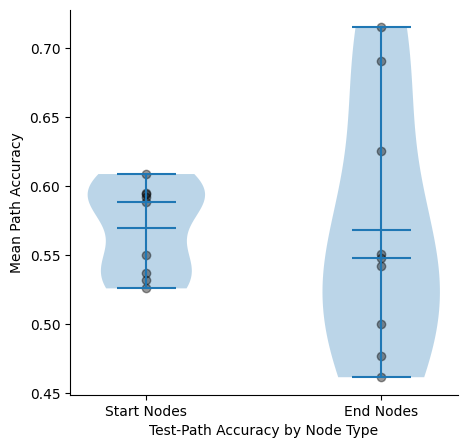


Summary Statistics of Path Accuracies by Start Node:
count    9.000000
mean     0.569433
std      0.032441
min      0.525886
25%      0.537190
50%      0.588710
75%      0.594521
max      0.608696
Name: accuracy, dtype: float64

Summary Statistics of Path Accuracies by End Node:
count    9.000000
mean     0.567902
std      0.090596
min      0.461538
25%      0.500000
50%      0.548105
75%      0.625683
max      0.715013
Name: accuracy, dtype: float64


In [64]:
# First simple plot
path_accuracies_by_start = test_df.groupby(["StartAt"])["accuracy"].mean().reset_index()
path_accuracies_by_end = test_df.groupby(["EndAt"])["accuracy"].mean().reset_index()

# Create a violin plot to show probability distribution
plt.figure(figsize=(5,5))
plt.violinplot([path_accuracies_by_start["accuracy"], path_accuracies_by_end["accuracy"]], showmeans=True, showmedians=True)

# Add scatter points
plt.scatter(np.ones(len(path_accuracies_by_start["accuracy"])), path_accuracies_by_start["accuracy"], alpha=0.4, color="black")
plt.scatter(2 * np.ones(len(path_accuracies_by_end["accuracy"])), path_accuracies_by_end["accuracy"], alpha=0.4, color="black")

plt.xticks([1, 2], ['Start Nodes', 'End Nodes'])

plt.grid(True, linestyle='--', alpha=0.7)
plt.xlabel('Test-Path Accuracy by Node Type')
plt.ylabel('Mean Path Accuracy')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(False)

plt.show()

# Show summary statistics
print("\nSummary Statistics of Path Accuracies by Start Node:")
print(path_accuracies_by_start['accuracy'].describe())

print("\nSummary Statistics of Path Accuracies by End Node:")
print(path_accuracies_by_end['accuracy'].describe())


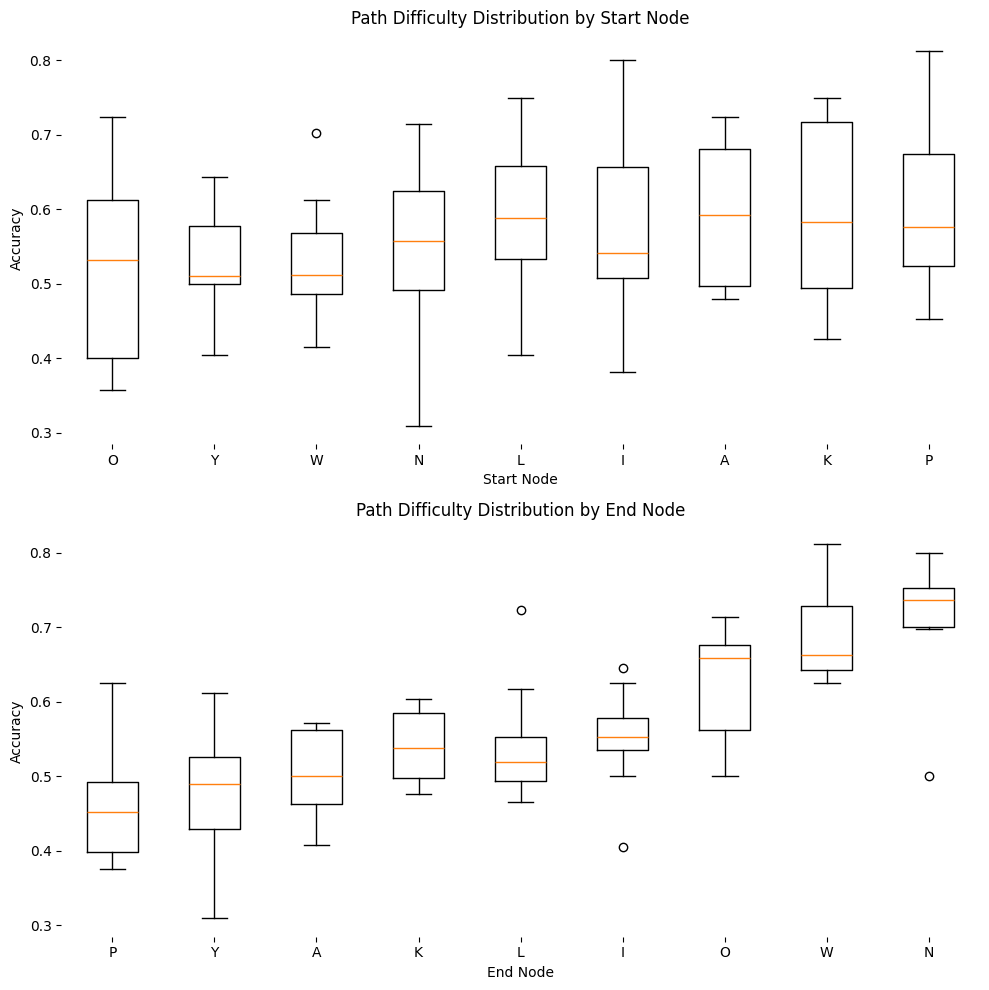

In [78]:
# Create visualization of accuracies by start and end nodes
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# Calculate mean accuracy per start node to determine order
start_node_means = test_df.groupby('StartAt')['accuracy'].mean()
node_order = start_node_means.sort_values(ascending=True).index

# 1. Box plots of path accuracies grouped by start node
path_data = []
for i in node_order:
    node_data = test_df[test_df['StartAt'] == i].groupby("StartEnd")["accuracy"].apply(np.mean)
    path_data.append(node_data.values)

bp = ax1.boxplot(path_data)

ax1.set_xlabel('Start Node')
ax1.set_ylabel('Accuracy')
ax1.set_title('Path Difficulty Distribution by Start Node')
ax1.set_xticks(range(1, len(node_order) + 1), list(node_order))
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.spines['bottom'].set_visible(False)

# Calculate mean accuracy per end node to determine order
end_node_means = test_df.groupby('EndAt')['accuracy'].mean()
node_order = end_node_means.sort_values(ascending=True).index

# 2. Box plots of path accuracies grouped by end node
path_data = []
for i in node_order:
    node_data = test_df[test_df['EndAt'] == i].groupby("StartEnd")["accuracy"].apply(np.mean)
    path_data.append(node_data.values)

bp = ax2.boxplot(path_data)

ax2.set_xlabel('End Node')
ax2.set_ylabel('Accuracy')
ax2.set_title('Path Difficulty Distribution by End Node')
ax2.set_xticks(range(1, len(node_order) + 1), list(node_order))
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['bottom'].set_visible(False)

plt.tight_layout()
plt.show()

### Statistics

In [80]:
# One-way ANOVA for start nodes
start_groups = [group["accuracy"].values for name, group in test_df.groupby("StartAt")]
f_stat_start, p_val_start = stats.f_oneway(*start_groups)

print("One-way ANOVA results for Start Nodes:")
print(f"F-statistic: {f_stat_start:.4f}")
print(f"p-value: {p_val_start:.8f}")

# ANOVA for end nodes  
end_groups = [group["accuracy"].values for name, group in test_df.groupby("EndAt")]
f_stat_end, p_val_end = stats.f_oneway(*end_groups)

print("\nOne-way ANOVA results for End Nodes:")
print(f"F-statistic: {f_stat_end:.4f}") 
print(f"p-value: {p_val_end:.8f}")

One-way ANOVA results for Start Nodes:
F-statistic: 1.5805
p-value: 0.12517146

One-way ANOVA results for End Nodes:
F-statistic: 12.9416
p-value: 0.00000000


In [82]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# For start nodes
print("\nSignificant pairwise comparisons for Start Nodes:")
# Prepare data for Tukey's test
start_data = test_df[['StartAt', 'accuracy']].copy()
# Perform Tukey's test
tukey_start = pairwise_tukeyhsd(start_data['accuracy'], start_data['StartAt'])
# Print only significant differences
summary = tukey_start.summary()
significant_rows = [i for i, reject in enumerate(tukey_start.reject) if reject]
for row in significant_rows:
    print(summary[row])

# For end nodes  
print("\nSignificant pairwise comparisons for End Nodes:")
# Prepare data for Tukey's test
end_data = test_df[['EndAt', 'accuracy']].copy()
# Perform Tukey's test
tukey_end = pairwise_tukeyhsd(end_data['accuracy'], end_data['EndAt'])
# Print only significant differences
summary = tukey_end.summary()
significant_rows = [i for i, reject in enumerate(tukey_end.reject) if reject]
for row in significant_rows:
    print(summary[row])

# Using pairwise t-tests with Bonferroni correction
from scipy.stats import ttest_ind
from itertools import combinations

def perform_pairwise_tests(df, node_column):
    nodes = df[node_column].unique()
    results = []
    for n1, n2 in combinations(nodes, 2):
        group1 = df[df[node_column] == n1]['accuracy']
        group2 = df[df[node_column] == n2]['accuracy']
        t_stat, p_val = ttest_ind(group1, group2)
        results.append({
            'Node1': n1,
            'Node2': n2,
            't_statistic': t_stat,
            'p_value': p_val
        })
    return pd.DataFrame(results)
    

# Get significant pairwise comparisons for start nodes
print("\nSignificant pairwise t-tests for Start Nodes (with Bonferroni correction):")
start_comparisons = perform_pairwise_tests(test_df, 'StartAt')
# Apply Bonferroni correction
n_comparisons = len(start_comparisons)
start_comparisons['adjusted_p'] = start_comparisons['p_value'] * n_comparisons
# Print only significant differences (p < 0.05)
print(start_comparisons[start_comparisons['adjusted_p'] < 0.05])


Significant pairwise comparisons for Start Nodes:

Significant pairwise comparisons for End Nodes:
[<statsmodels.iolib.table.Cell object at 0x2977eb350>, <statsmodels.iolib.table.Cell object at 0x2977eb0d0>, <statsmodels.iolib.table.Cell object at 0x2977eb490>, <statsmodels.iolib.table.Cell object at 0x2977eb450>, <statsmodels.iolib.table.Cell object at 0x2977eb3d0>, <statsmodels.iolib.table.Cell object at 0x2977eba50>, <statsmodels.iolib.table.Cell object at 0x2977eb950>]
[<statsmodels.iolib.table.Cell object at 0x2977eb4d0>, <statsmodels.iolib.table.Cell object at 0x2977ebe50>, <statsmodels.iolib.table.Cell object at 0x2977ebc10>, <statsmodels.iolib.table.Cell object at 0x2977eb890>, <statsmodels.iolib.table.Cell object at 0x2977ebf50>, <statsmodels.iolib.table.Cell object at 0x2977ebed0>, <statsmodels.iolib.table.Cell object at 0x2977ead90>]
[<statsmodels.iolib.table.Cell object at 0x297800b90>, <statsmodels.iolib.table.Cell object at 0x297801410>, <statsmodels.iolib.table.Cell obj

## 7. Heatmaps and foils (Fig. 3E)

In [88]:
# Create heatmap of accuracies
acc_matrix = np.zeros((len(OBJECTS), len(OBJECTS)))

# First calculate accuracies and end node averages
end_node_avgs = {}
for end in OBJECTS:
    end_accs = []
    for start in OBJECTS:
        if start != end:
            acc = np.mean(test_df[(test_df["StartAt"]==start) & 
                                (test_df["EndAt"]==end)]["accuracy"])
            end_accs.append(acc)
    end_node_avgs[end] = np.mean(end_accs)

# Sort OBJECTS by end node average accuracy
sorted_objects = sorted(OBJECTS, key=lambda x: end_node_avgs[x], reverse=True)

# Create matrix with sorted indices
for i, start in enumerate(sorted_objects):
    for j, end in enumerate(sorted_objects):
        if start != end:
            acc = np.mean(test_df[(test_df["StartAt"]==start) & 
                                (test_df["EndAt"]==end)]["accuracy"])
            acc_matrix[i,j] = acc
        else:
            acc_matrix[i,j] = np.nan  # Set diagonal to NaN instead of 0

fig = go.Figure(data=go.Heatmap(
    z=acc_matrix,
    x=list(sorted_objects),
    y=list(sorted_objects),
    colorscale='RdBu',
    text=np.round(acc_matrix, 3),
    texttemplate='%{text}',
    textfont={"size": 10},
    colorbar=dict(title='Accuracy'),
    zmin=np.nanmin(acc_matrix),  # Ignore NaN values when setting scale
    zmax=np.nanmax(acc_matrix)
))

fig.update_layout(
    title='Path Accuracies by Start and End Nodes',
    xaxis_title='End Node',
    yaxis_title='Start Node',
    width=600,
    height=600,
)

fig.show()

Winners w/ other object: total=45 mean=0.02
Losers w/ other object not end: total=182 mean=0.13
Losers end other object: total=897 mean=0.63


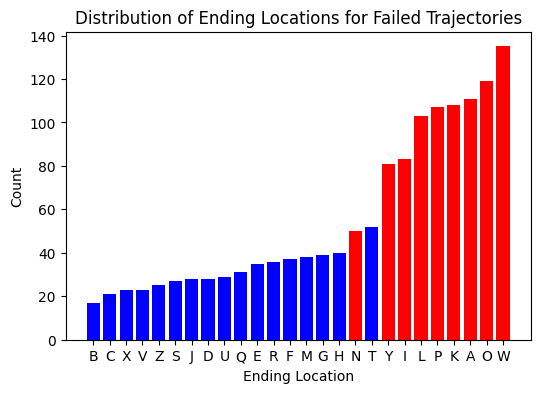

In [3]:
#### Looking for common foilsOBJECTS = "AIKLNOPWY"

def contains_other_obj(traj, start, end):
    for obj in OBJECTS:
        if obj != start and obj != end:
            if obj in traj:
                return True
    return False

winner_objects = []
loser_objects = []
loser_end_object = []
loser_ends = {}
for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    trajs = generate_trajs_from_df(group)
    accs = np.array(group["accuracy"])
    
    for traj, acc in zip(trajs, accs):
        if acc:
            winner_objects.append(contains_other_obj(traj[:-2], start_node, end_node))
        else:
            loser_objects.append(contains_other_obj(traj[:-2], start_node, end_node)) # sometimes it is double end bc button?
            
            end_node = traj[-1][-1]
            loser_end_object.append(end_node in OBJECTS)

            loser_ends[end_node] = loser_ends.get(end_node, 0) + 1


    
print(f"Winners w/ other object: total={np.sum(winner_objects)} mean={np.mean(winner_objects):.2f}")
print(f"Losers w/ other object not end: total={np.sum(loser_objects)} mean={np.mean(loser_objects):.2f}")
print(f"Losers end other object: total={np.sum(loser_end_object)} mean={np.mean(loser_end_object):.2f}")

plt.figure(figsize=(6, 4))

# Sort the data by count
sorted_items = sorted(loser_ends.items(), key=lambda x: x[1])
locations, counts = zip(*sorted_items)

# Create color list - objects in red, other locations in blue
colors = ["red" if loc in OBJECTS else "blue" for loc in locations]

plt.bar(locations, counts, color=colors)
plt.title("Distribution of Ending Locations for Failed Trajectories")
plt.xlabel("Ending Location")
plt.ylabel("Count")
plt.show()



Most common failure modes:
--------------------------------------------------
Target: A            | Most common failure: L            | Count:   29 | Pct: 0.16
Target: I            | Most common failure: K            | Count:   22 | Pct: 0.13
Target: K            | Most common failure: O            | Count:   28 | Pct: 0.17
Target: L            | Most common failure: A            | Count:   25 | Pct: 0.16
Target: N            | Most common failure: F            | Count:   16 | Pct: 0.14
Target: O            | Most common failure: K            | Count:   25 | Pct: 0.18
Target: P            | Most common failure: Y            | Count:   30 | Pct: 0.15
Target: W            | Most common failure: P            | Count:   17 | Pct: 0.15
Target: Y            | Most common failure: W            | Count:   25 | Pct: 0.13
--------------------------------------------------


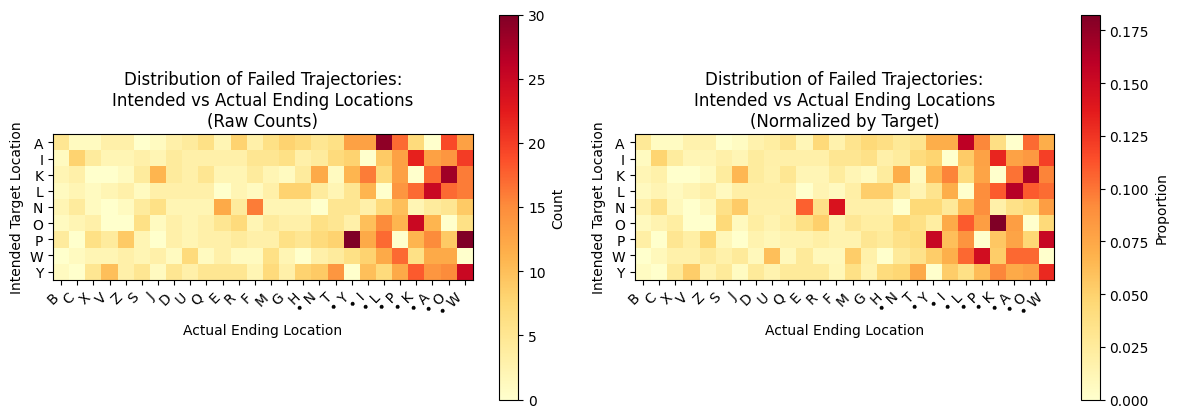

In [4]:
# Create a 2D grid of actual vs intended end locations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))

# Get unique end locations - objects only for y-axis (intended targets)
target_locations = sorted(set(OBJECTS))

# Sort actual locations by frequency like in bar plot
actual_locations = [loc for loc, _ in sorted(loser_ends.items(), key=lambda x: x[1])]
# Add any missing locations from test_df that weren't in loser_ends
remaining_locs = set(test_df['EndAt'].unique()) - set(actual_locations)
actual_locations.extend(sorted(remaining_locs))

# Create a matrix of counts
counts_matrix = np.zeros((len(target_locations), len(actual_locations)))

# Fill the matrix
for (_, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    trajs = generate_trajs_from_df(group)
    for traj in trajs:
        actual_end = traj[-1][-1]
        if actual_end != end_node:  # Only count failures
            i = target_locations.index(end_node)
            j = actual_locations.index(actual_end)
            counts_matrix[i, j] += 1

# Create normalized matrix
norm_matrix = counts_matrix / counts_matrix.sum(axis=1, keepdims=True)

# Print max failure count for each intended target
print("\nMost common failure modes:")
print("-" * 50)
for i, target in enumerate(target_locations):
    max_count = counts_matrix[i].max()
    max_idx = counts_matrix[i].argmax()
    actual = actual_locations[max_idx]
    max_norm = norm_matrix[i][max_idx]
    print(f"Target: {target:12} | Most common failure: {actual:12} | Count: {int(max_count):4} | Pct: {max_norm:.2f}")
print("-" * 50)


# Create heatmaps
for ax, matrix, title_suffix, label in [
    (ax1, counts_matrix, 'Raw Counts', 'Count'),
    (ax2, norm_matrix, 'Normalized by Target', 'Proportion')
]:
    im = ax.imshow(matrix, cmap='YlOrRd')
    plt.colorbar(im, ax=ax, label=label, shrink=0.5)
    
    # Set labels with different colors for objects vs other locations
    x_labels = [f'\u2022 {loc}' if loc in OBJECTS else loc for loc in actual_locations]
    ax.set_xticks(range(len(actual_locations)))
    ax.set_xticklabels(x_labels, rotation=45, ha='right')
    ax.set_yticks(range(len(target_locations)))
    ax.set_yticklabels(target_locations)
    
    ax.set_xlabel('Actual Ending Location')
    ax.set_ylabel('Intended Target Location')
    ax.set_title(f'Distribution of Failed Trajectories:\nIntended vs Actual Ending Locations\n({title_suffix})')

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()



Most common failure modes (objects only):
--------------------------------------------------
Target: N            | Most common failure: P            | Count:   10 | Pct: 0.22
Target: Y            | Most common failure: W            | Count:   25 | Pct: 0.23
Target: I            | Most common failure: K            | Count:   22 | Pct: 0.21
Target: L            | Most common failure: A            | Count:   25 | Pct: 0.23
Target: P            | Most common failure: Y            | Count:   30 | Pct: 0.23
Target: K            | Most common failure: O            | Count:   28 | Pct: 0.23
Target: A            | Most common failure: L            | Count:   29 | Pct: 0.25
Target: O            | Most common failure: K            | Count:   25 | Pct: 0.29
Target: W            | Most common failure: P            | Count:   17 | Pct: 0.22
--------------------------------------------------


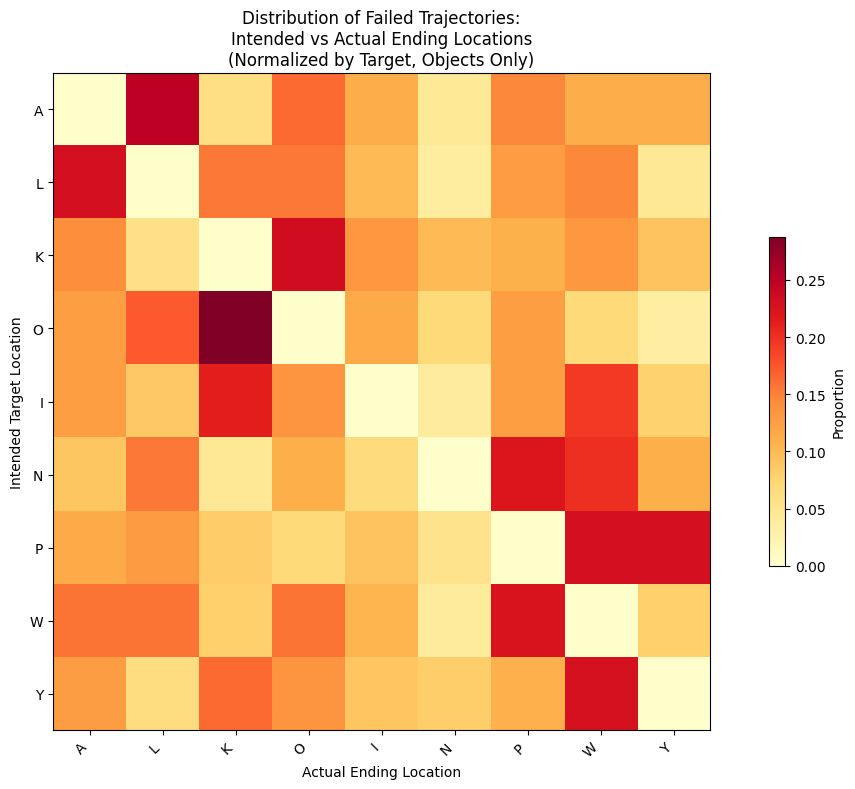

In [6]:
# Create a figure with just normalized heatmap
fig, ax = plt.subplots(figsize=(12, 8))

# Get unique end locations - objects only for y-axis (intended targets)
# OBJECTS = "OYNPALWKI"

# Sort actual locations by frequency like in bar plot
actual_locations = [loc for loc, _ in sorted(loser_ends.items(), key=lambda x: x[1])]
# Add any missing locations from test_df that weren't in loser_ends
remaining_locs = set(test_df['EndAt'].unique()) - set(actual_locations)
actual_locations.extend(sorted(remaining_locs))
# Filter to only show objects
actual_locations = [loc for loc in actual_locations if loc in OBJECTS]

# Use same order for target locations
target_locations = actual_locations.copy()

# Create a matrix of counts
counts_matrix = np.zeros((len(target_locations), len(actual_locations)))

# Fill the matrix
for (_, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    trajs = generate_trajs_from_df(group)
    for traj in trajs:
        actual_end = traj[-1][-1]
        if actual_end != end_node and actual_end in OBJECTS:  # Only count failures to objects
            i = target_locations.index(end_node)
            j = actual_locations.index(actual_end)
            counts_matrix[i, j] += 1

# Create normalized matrix
norm_matrix = counts_matrix / counts_matrix.sum(axis=1, keepdims=True)

# Print max failure count for each intended target
print("\nMost common failure modes (objects only):")
print("-" * 50)
for i, target in enumerate(target_locations):
    max_count = counts_matrix[i].max()
    max_idx = counts_matrix[i].argmax()
    actual = actual_locations[max_idx]
    max_norm = norm_matrix[i][max_idx]
    print(f"Target: {target:12} | Most common failure: {actual:12} | Count: {int(max_count):4} | Pct: {max_norm:.2f}")
print("-" * 50)

# Define desired order
desired_order = list("ALKOINPWY")

# Reorder matrices according to desired order
order_idx_actual = [actual_locations.index(loc) for loc in desired_order if loc in actual_locations]
order_idx_target = [target_locations.index(loc) for loc in desired_order if loc in target_locations]

norm_matrix = norm_matrix[order_idx_target][:, order_idx_actual]
actual_locations = [actual_locations[i] for i in order_idx_actual]
target_locations = [target_locations[i] for i in order_idx_target]

# Create heatmap
im = ax.imshow(norm_matrix, cmap='YlOrRd')
plt.colorbar(im, ax=ax, label='Proportion', shrink=0.5)

# Set labels
ax.set_xticks(range(len(actual_locations)))
ax.set_xticklabels(actual_locations, rotation=45, ha='right')
ax.set_yticks(range(len(target_locations)))
ax.set_yticklabels(target_locations)

ax.set_xlabel('Actual Ending Location')
ax.set_ylabel('Intended Target Location')
ax.set_title('Distribution of Failed Trajectories:\nIntended vs Actual Ending Locations\n(Normalized by Target, Objects Only)')

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()


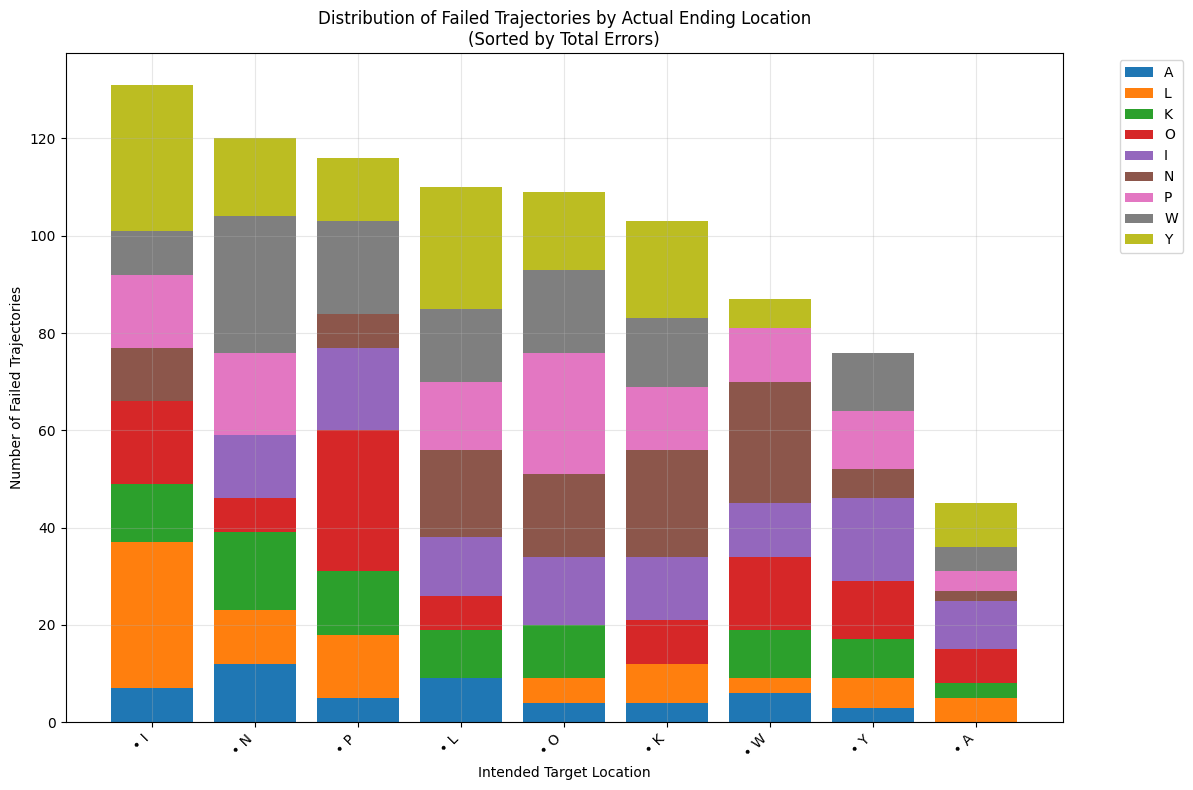

In [7]:
only_use_objects = True

# Create a figure
plt.figure(figsize=(12, 8))

# Calculate total errors for each target location
total_errors = counts_matrix.sum(axis=1)
sorted_indices = np.argsort(total_errors)[::-1]  # Sort in descending order

# Create stacked bar plot
bottom = np.zeros(len(target_locations))
for i, actual in enumerate(actual_locations):
    if (not only_use_objects) or (actual in OBJECTS):
        # Use sorted_indices to index into counts_matrix correctly
        values = counts_matrix.T[i][sorted_indices]  # Transpose to get actual location values
        plt.bar(range(len(target_locations)), values,
               bottom=bottom, label=actual)
        bottom += values

# Set x-axis labels with dots for objects, using sorted order
x_labels = [f'\u2022 {target_locations[i]}' if target_locations[i] in OBJECTS else target_locations[i] 
           for i in sorted_indices]
plt.xticks(range(len(target_locations)), x_labels, rotation=45, ha='right')

plt.xlabel('Intended Target Location')
plt.ylabel('Number of Failed Trajectories')
plt.title('Distribution of Failed Trajectories by Actual Ending Location\n(Sorted by Total Errors)')

# Add legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()


## 8. Miscellaneous Archive

Interactive test path figure, by StartEnd

## Plotting function

In [84]:
# Function to create traces for the bars and the dotted line for average accuracy
def create_trace(data, color_column, group_column, name):
    traces = []
    tickvals = []
    ticktext = []
    
    for group in data[group_column].unique():
        group_data = data[data[group_column] == group]
        # Bar trace
        bar_trace = go.Bar(
            x=group_data["StartEnd"],
            y=group_data["accuracy"],
            marker=dict(color=group_data[color_column]),
            opacity=0.7,
            # name=f"{name}: {group}",
            hovertemplate=(
                f"<br>" +
                "%{customdata}, %{y:.2f}<extra></extra>"
            ),
            customdata=group_data["StartEnd"],
            showlegend=False
        )
        traces.append(bar_trace)
        
        # Dotted line for average accuracy
        avg_accuracy = group_data["accuracy"].mean()
        line_trace = go.Scatter(
            x=group_data["StartEnd"],
            y=[avg_accuracy] * len(group_data),
            mode='lines',
            line=dict(dash='dot', color=group_data[color_column].iloc[0], width=2),
            name=f"Avg {name}: {group}, {avg_accuracy}",
            hovertemplate=(
                f"<b>{name}: {group}</b><br>" +
                "Avg Accuracy: %{y:.2f}<extra></extra>"
            ),
            showlegend=False
        )
        traces.append(line_trace)

        # Custom tick text for the x-axis, center the tick text
        mid_index = len(group_data) // 2
        tickvals.append(group_data["StartEnd"].iloc[mid_index])
        ticktext.append(group)
    
    return traces, tickvals, ticktext

## Do the plotting

In [92]:
# Assuming test_df is your initial DataFrame
new_df = test_df.groupby(["StartAt", "EndAt"])["accuracy"].mean().reset_index()
new_df["StartEnd"] = new_df["StartAt"] + "_" + new_df["EndAt"]

# Calculate min turns; first set turns very high for the wrong people
# Note: there's definitely a smarter way to do this in pandas
test_df["accuracy"] = test_df["accuracy"].astype(bool)
test_df["fake_turns"] = test_df["turns_count"]
test_df.loc[~test_df["accuracy"], "fake_turns"] = 999

test_df["min_turns"] = test_df.groupby("StartEnd")["fake_turns"].transform("min")

# Calculate min path dist; first set v high for the wrong people
# Note: there's definitely a smarter way to do this in pandas
test_df["fake_dist"] = test_df["trajs"].apply(len)
test_df.loc[~test_df["accuracy"], "fake_dist"] = 999

test_df["min_dist"] = test_df.groupby("StartEnd")["fake_dist"].transform("min")

print(new_df)
color_dict = {k: f'rgb({v[0]*255},{v[1]*255},{v[2]*255})' for k, v in zip(new_df["StartAt"].unique(), plt.get_cmap('tab20').colors)}

# # Create the layout for subplots
fig = make_subplots(rows=3, cols=1, vertical_spacing=0.1, subplot_titles=("Grouped by StartAt", "Grouped by EndAt", "Sorted with metrics"))

# Sorting by StartAt
avg_startat = new_df.groupby("StartAt")["accuracy"].mean().sort_values()
new_df["StartAt"] = pd.Categorical(new_df["StartAt"], categories=avg_startat.index, ordered=True)
new_df = new_df.sort_values(["StartAt", "accuracy"])
new_df["colors_start"] = new_df["StartAt"].apply(lambda x: color_dict[x])

# Add traces for StartAt groups
traces_start, tickvals_start, ticktext_start = create_trace(new_df, "colors_start", "StartAt", "StartAt")
for trace in traces_start:
    fig.add_trace(trace, row=1, col=1)
  
# Sorting by EndAt
avg_endat = new_df.groupby("EndAt")["accuracy"].mean().sort_values()
new_df["EndAt"] = pd.Categorical(new_df["EndAt"], categories=avg_endat.index, ordered=True)
new_df = new_df.sort_values(["EndAt", "accuracy"])
new_df["colors_end"] = new_df["EndAt"].apply(lambda x: color_dict[x])

# Add traces for EndAt groups
traces_end, tickvals_end, ticktext_end = create_trace(new_df, "colors_end", "EndAt", "EndAt")
for trace in traces_end:
    fig.add_trace(trace, row=2, col=1)

## Add third plot
# Assuming test_df is your initial DataFrame
metrics_to_plot = ["min_dist", "min_turns", "Euc.Distance", "Path.Distance"]
colors = ["red", "blue", "yellow", "orange"]

# Prepare data
path_accs = test_df[["StartEnd", "path_mean_acc"] + metrics_to_plot].drop_duplicates(subset=["StartEnd"], keep="first")
path_accs = path_accs.sort_values("path_mean_acc")

# Bar plot for path mean accuracy
bar_trace = go.Bar(
    x=path_accs["StartEnd"],
    y=path_accs["path_mean_acc"]*45,
    marker=dict(color="rgba(0, 0, 0, 0.1)"),
    name="Path Mean Accuracy",
    xaxis="x3",
    yaxis="y11",
    hovertemplate="StartEnd: %{x}<br>Path Mean Accuracy: %{customdata:.2f}<extra></extra>",
    customdata=path_accs["path_mean_acc"],

)
fig.add_trace(bar_trace, row=3, col=1)

# Scatter plots for metrics
for metric, color in zip(metrics_to_plot, colors):
    scatter_trace = go.Scatter(
        x=path_accs["StartEnd"],
        y=path_accs[metric],
        mode='markers',
        marker=dict(color=color),
        name=metric,
        xaxis="x3",
        yaxis="y12"
        # hovertemplate=f"StartEnd: <br>{metric}: %{y:.2f}<extra></extra>"#%{x}
    )
    fig.add_trace(scatter_trace, row=3, col=1)

# Update layout for color legends and custom ticks
fig.update_layout(
    height=800, width=800,
    showlegend=True,
    legend=dict(
        x=1.05,
        y=-10,
        traceorder='normal'
    ),
    xaxis=dict(
        tickvals=tickvals_start,
        ticktext=ticktext_start,
        tickmode='array'
    ),
    xaxis2=dict(
        tickvals=tickvals_end,
        ticktext=ticktext_end,
        tickmode='array',
    ),
    yaxis11=dict(title="Path Mean Accuracy", anchor="x3"),
    yaxis12=dict(title="Metrics", anchor="x3", overlaying='y7', side='right'),
)

fig.update_layout(hovermode="closest")

fig.show()
plot(fig, filename="figures/grouped_by_start_end.html")

   StartAt EndAt  accuracy StartEnd
0        A     I  0.500000      A_I
1        A     K  0.488372      A_K
2        A     L  0.723404      A_L
3        A     N  0.723404      A_N
4        A     O  0.666667      A_O
..     ...   ...       ...      ...
67       Y     L  0.520833      Y_L
68       Y     N  0.500000      Y_N
69       Y     O  0.562500      Y_O
70       Y     P  0.625000      Y_P
71       Y     W  0.642857      Y_W

[72 rows x 4 columns]


'figures/grouped_by_start_end.html'